# Análisis Exploratorio de Datos (EDA): Colombia EVA

**Propósito del trabajo:** evaluar la idoneidad del dataset para aprendizaje automático, identificando su contenido, problemas de calidad, transformaciones necesarias y viabilidad para entrenamiento de modelos.

**Pregunta central:** ¿el dataset Colombia EVA puede dejarse listo para modelado supervisado (clasificación o regresión) cumpliendo criterios técnicos y de calidad?

**Materia:** Programación Avanzada

**Profesor:** Jaime Alberto Vergara Tejada

**Estudiante:** Diego Alejandro Ríos Vásquez

**Fuente de datos:** Datos.gov.co (API Socrata SODA)

**Dataset ID:** 2pnw-mmge

**Endpoint:** https://www.datos.gov.co/api/v3/views/2pnw-mmge/query.json

---

Este notebook está redactado como informe técnico: cada sección explica el objetivo analítico, la justificación del procedimiento y la interpretación de resultados.

## Resumen Ejecutivo

Este informe evalúa la viabilidad del dataset **Colombia EVA** para aprendizaje automático, con base en criterios de calidad, estructura y capacidad predictiva.

### Resultados principales

- **Volumen de datos:** se trabajó con **1000 registros** y **17 variables**, cumpliendo el criterio de tamaño mínimo preferible.
- **Variables numéricas:** tras estandarización de tipos (la API entrega múltiples columnas como texto), se identificaron **7 variables numéricas**, superando el mínimo exigido de 5.
- **Variable objetivo:** se definió **`ciclo_de_cultivo`** como objetivo de **clasificación multiclase** (3 clases), adecuada para modelado supervisado.
- **Calidad de datos:** se detectaron faltantes relevantes en `rendimiento_t_ha` (6.8%) y un faltante puntual en `municipio` (0.1%); no se identificaron duplicados exactos en la muestra analizada.
- **Distribuciones y outliers:** se observaron asimetrías y valores extremos en variables productivas, lo que justifica transformaciones y tratamiento robusto previo al entrenamiento.
- **Relación entre variables:** el análisis de correlación permitió identificar relaciones útiles y posibles redundancias a validar antes del modelado final.
- **Relación con la variable objetivo:** se incluyó evaluación de separabilidad por variables numéricas y detección de variables potencialmente poco informativas.
- **Balance de clases:** se revisó la distribución de la variable objetivo y sus implicaciones para partición estratificada y métricas de evaluación.

### ¿Por qué este dataset sí cumple la rúbrica?

1. Cumple con el volumen recomendado (>= 1000 registros).
2. Cumple con el requisito de al menos 5 variables numéricas (7 detectadas tras tipificación).
3. Cuenta con una variable objetivo explícita y modelable (`ciclo_de_cultivo`).
4. Incluye revisión de calidad de datos (faltantes, inconsistencias, duplicados e imposibles).
5. Incluye análisis de distribuciones, correlación, relación con objetivo y balance de clases.
6. El documento está estructurado como **informe técnico**, no como una secuencia aislada de comandos.

### Conclusión ejecutiva

El dataset es **apto para continuar a la fase de entrenamiento**, siempre que se mantenga el preprocesamiento documentado en este informe (tipificación numérica, tratamiento de faltantes, revisión de outliers y validación estratificada por clases).

## 1. Configuración del entorno e importaciones

In [74]:
# Instala sodapy solo si no está disponible en el entorno
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('sodapy') is None:
    print('Instalando sodapy...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sodapy', '-q'])
    print('sodapy instalado correctamente.')
else:
    print('sodapy ya está disponible.')

sodapy ya está disponible.


In [75]:
import sys
import os
import warnings
from datetime import datetime

# Avoid circular import caused by local module shadowing pandas (e.g., pandas.py)
cwd = os.getcwd()
removed_paths = []

for p in (cwd, ''):
	if p in sys.path:
		sys.path.remove(p)
		removed_paths.append(p)

if 'pandas' in sys.modules:
	del sys.modules['pandas']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sodapy import Socrata

# Restore removed paths
for p in reversed(removed_paths):
	sys.path.insert(0, p)

warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print(' Libraries imported successfully!')
print(f' Execution timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

 Libraries imported successfully!
 Execution timestamp: 2026-04-24 12:00:08


## 2. Configuración de la fuente de datos (Datos.gov.co)

In [76]:
# Configuración para API Socrata (Datos.gov.co)
# Documentación: https://datos.gov.co/

from pathlib import Path

DOMAIN = 'datos.gov.co'
DATASET_ID = '2pnw-mmge'  # Dataset oficial Colombia EVA

# Carga automática de variables desde .env
env_path = Path('.env')
loaded_from_env = False

if env_path.exists():
    try:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path=env_path, override=False)
        loaded_from_env = True
    except Exception:
        # Fallback sin dependencias externas
        for line in env_path.read_text(encoding='utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('#') or '=' not in line:
                continue
            key, value = line.split('=', 1)
            key = key.strip()
            value = value.strip().strip('"').strip("'")
            os.environ.setdefault(key, value)
        loaded_from_env = True

# Variables de entorno esperadas:
# - DATOSABIERTOS_API_KEY
# - DATOSABIERTOS_API_SECRET
# - DATOSABIERTOS_APP_TOKEN (opcional; si no existe, se usa API_KEY como token)
API_KEY_ID = os.environ.get('DATOSABIERTOS_API_KEY')
API_SECRET = os.environ.get('DATOSABIERTOS_API_SECRET')
APP_TOKEN = os.environ.get('DATOSABIERTOS_APP_TOKEN') or API_KEY_ID

if APP_TOKEN and API_SECRET:
    auth_msg = 'Configurada (API Key + Secret)'
elif APP_TOKEN:
    auth_msg = 'Configurada (solo token/app token)'
else:
    auth_msg = 'Sin credenciales (modo publico; puede tener limites de tasa)'

print('Configuracion de Datos.gov.co:')
print(f'  Dominio: {DOMAIN}')
print(f'  Dataset ID: {DATASET_ID}')
print(f'  Dataset: Colombia EVA')
print(f'  .env cargado: {"Si" if loaded_from_env else "No"}')
print(f'  Autenticacion: {auth_msg}')
print(f'  API Key detectada: {"Si" if API_KEY_ID else "No"}')
print(f'  API Secret detectado: {"Si" if API_SECRET else "No"}')

Configuracion de Datos.gov.co:
  Dominio: datos.gov.co
  Dataset ID: 2pnw-mmge
  Dataset: Colombia EVA
  .env cargado: Si
  Autenticacion: Configurada (API Key + Secret)
  API Key detectada: Si
  API Secret detectado: Si


### Nota metodológica sobre la fuente de datos

El conjunto se consulta desde el portal oficial de datos abiertos de Colombia mediante la API SODA.

Criterios de selección aplicados:
- Disponibilidad pública y trazabilidad de la fuente.
- Volumen suficiente para análisis estadístico inicial.
- Presencia potencial de múltiples variables cuantitativas y una variable objetivo.

Pasos de consulta reproducible:
1. Ingresar a https://datos.gov.co/.
2. Verificar identificador del recurso (`2pnw-mmge`).
3. Consumir registros vía API para análisis exploratorio.

Ejemplo de consulta:

```python
results = client.get('2pnw-mmge', limit=1000)
df = pd.DataFrame.from_records(results)
```

## 3. Carga de datos

In [77]:
def fetch_data_from_soda(domain, dataset_id, app_token=None, limit=None, page_size=1000):
    """Obtiene datos desde Datos.gov.co usando API SODA con paginacion."""

    def _request_with_pagination(token):
        client = Socrata(domain, token, timeout=60)

        # Si no se define limite, se hace una consulta simple (comportamiento conservador).
        if limit is None:
            print('  Consulta sin limite explicito (respuesta por defecto del API).')
            return client.get(dataset_id)

        rows = []
        offset = 0

        while len(rows) < limit:
            batch_limit = min(page_size, limit - len(rows))
            print(f'  Solicitando lote: offset={offset:,}, limit={batch_limit:,}')
            batch = client.get(dataset_id, limit=batch_limit, offset=offset)

            if not batch:
                break

            rows.extend(batch)
            offset += len(batch)

            # Si el API retorna menos de lo pedido, no hay mas datos disponibles en esta consulta.
            if len(batch) < batch_limit:
                break

        return rows

    try:
        print(f'Conectando a {domain}...')
        print(f'Consultando dataset {dataset_id}...')
        results = _request_with_pagination(app_token)

        if not results:
            print('Error: la consulta retorno resultados vacios.')
            return None

        df = pd.DataFrame.from_records(results)
        print('Datos cargados correctamente.')
        print(f'  Tamano: {df.shape[0]:,} filas x {df.shape[1]} columnas')
        return df

    except Exception as e:
        msg = str(e)
        # Si el token es invalido, reintenta en modo publico.
        if app_token and ('Invalid app_token' in msg or '403' in msg):
            try:
                print('Token invalido o rechazado. Reintentando sin token...')
                results = _request_with_pagination(None)
                if not results:
                    print('Error: la consulta sin token retorno resultados vacios.')
                    return None
                df = pd.DataFrame.from_records(results)
                print('Datos cargados correctamente en modo publico.')
                print(f'  Tamano: {df.shape[0]:,} filas x {df.shape[1]} columnas')
                return df
            except Exception as e2:
                print(f'Error al reintentar sin token: {str(e2)}')
                return None

        print(f'Error al obtener datos: {msg}')
        print('\nSugerencias de validacion:')
        print(f'  1. Verifica DATASET_ID (actual: {dataset_id})')
        print('  2. Verifica conexion a internet')
        print('  3. Revisa disponibilidad del portal datos.gov.co')
        print('  4. Si usas token, valida que sea correcto')
        return None

In [78]:
# Carga principal del dataset
print('Iniciando consulta de datos...\n')

LOAD_LIMIT = 5000  # Se fuerza una muestra amplia para el informe
print(f'Se solicitaran {LOAD_LIMIT:,} registros al API.\n')

df = fetch_data_from_soda(
    domain=DOMAIN,
    dataset_id=DATASET_ID,
    app_token=APP_TOKEN,
    limit=LOAD_LIMIT
)

if df is not None and len(df) > 0:
    print('\nResumen inicial del dataset:')
    print(f'  Total de registros cargados: {df.shape[0]:,}')
    print(f'  Total de columnas: {df.shape[1]}')
    print('\nPrimeras filas:')
    display(df.head())
else:
    print('\nNo se logró cargar la data desde la API.')
    print('Alternativa: cargar un CSV local con la misma estructura.')
    print('Ejemplo: df = pd.read_csv("ruta/a/archivo.csv")')

Iniciando consulta de datos...

Se solicitaran 5,000 registros al API.

Conectando a datos.gov.co...
Consultando dataset 2pnw-mmge...
  Solicitando lote: offset=0, limit=1,000


Token invalido o rechazado. Reintentando sin token...
  Solicitando lote: offset=0, limit=1,000
  Solicitando lote: offset=1,000, limit=1,000
  Solicitando lote: offset=2,000, limit=1,000
  Solicitando lote: offset=3,000, limit=1,000
  Solicitando lote: offset=4,000, limit=1,000
Datos cargados correctamente en modo publico.
  Tamano: 5,000 filas x 17 columnas

Resumen inicial del dataset:
  Total de registros cargados: 5,000
  Total de columnas: 17

Primeras filas:


,c_d_dep,departamento,c_d_mun,municipio,grupo_de_cultivo,subgrupo_de_cultivo,cultivo,desagregaci_n_regional_y,a_o,periodo,rea_sembrada_ha,rea_cosechada_ha,producci_n_t,rendimiento_t_ha,estado_fisico_produccion,nombre_cientifico,ciclo_de_cultivo
0,15,BOYACA,15114,BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,25754,SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,82,80,1440,18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,25214,COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,54405,LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,3,3,48,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,54518,PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,1,1,5,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


### 3.1 Verificación de cumplimiento de requisitos de la entrega

En esta sección se estandarizan tipos de datos para validar formalmente el cumplimiento de la rúbrica del curso.

Se verifica:
- Al menos 5 variables numéricas.
- Una variable objetivo apta para clasificación o regresión.
- Tamaño suficiente del conjunto (mínimo de rúbrica y objetivo operativo del informe).

In [96]:
# Estandarización de columnas numéricas y chequeo de requisitos
if df is not None and len(df) > 0:
    # Columnas que representan magnitudes numéricas en este dataset
    numeric_candidates = [
        'c_d_dep', 'c_d_mun', 'a_o',
        'rea_sembrada_ha', 'rea_cosechada_ha',
        'producci_n_t', 'rendimiento_t_ha'
    ]

    for col in numeric_candidates:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print('Chequeo de requisitos del dataset:')
    print(f'- Registros cargados: {len(df):,}')
    print(f'- Variables numericas detectadas: {len(numeric_cols)}')
    print(f'  {numeric_cols}')

    # Propuesta de variable objetivo
    suggested_target = 'ciclo_de_cultivo' if 'ciclo_de_cultivo' in df.columns else None
    if suggested_target:
        n_classes = df[suggested_target].nunique(dropna=True)
        print(f'- Variable objetivo sugerida: {suggested_target} (clasificacion, {n_classes} clases)')
    else:
        print('- No se encontro una variable objetivo categorica obvia automaticamente.')

    # Validaciones: rubrica y objetivo operativo
    cumple_numericas = len(numeric_cols) >= 5
    cumple_registros_rubrica = len(df) >= 1000
    cumple_registros_operativo = len(df) >= 5000
    cumple_objetivo = suggested_target is not None

    print('\nResultado:')
    print(f'- Cumple >= 5 numericas: {"Si" if cumple_numericas else "No"}')
    print(f'- Cumple rubrica (>= 1000 registros): {"Si" if cumple_registros_rubrica else "No"}')
    print(f'- Cumple objetivo operativo (>= 5000 registros): {"Si" if cumple_registros_operativo else "No"}')
    print(f'- Tiene objetivo para modelado: {"Si" if cumple_objetivo else "No"}')

    if cumple_numericas and cumple_registros_rubrica and cumple_objetivo:
        print('\nConclusion: El dataset es apto para el trabajo y para modelado, con preprocesamiento.')
    else:
        print('\nConclusion: El dataset aun no cumple totalmente; se requiere ajuste adicional.')
else:
    print('No hay datos cargados. Ejecuta primero la carga desde API.')

Chequeo de requisitos del dataset:
- Registros cargados: 5,000
- Variables numericas detectadas: 7
  ['c_d_dep', 'c_d_mun', 'a_o', 'rea_sembrada_ha', 'rea_cosechada_ha', 'producci_n_t', 'rendimiento_t_ha']
- Variable objetivo sugerida: ciclo_de_cultivo (clasificacion, 3 clases)

Resultado:
- Cumple >= 5 numericas: Si
- Cumple rubrica (>= 1000 registros): Si
- Cumple objetivo operativo (>= 5000 registros): Si
- Tiene objetivo para modelado: Si

Conclusion: El dataset es apto para el trabajo y para modelado, con preprocesamiento.


## 1. Descripción del problema y definición de variable objetivo

Este dataset registra información agrícola por observación territorial y temporal (departamento, municipio, cultivo, periodo y métricas productivas).

Definiciones de análisis:
- **Unidad de análisis (fila):** un registro de cultivo en una combinación de territorio y periodo.
- **Variables explicativas:** características geográficas, productivas y de clasificación del cultivo.
- **Variable objetivo propuesta:** `ciclo_de_cultivo` (clasificación multiclase).

Justificación de la variable objetivo:
- Tiene interpretación agronómica directa.
- Permite un problema de clasificación supervisada.
- Es útil para evaluar separabilidad entre patrones productivos y territoriales.

In [97]:
# Configuración de la variable objetivo
TARGET_COLUMN = 'ciclo_de_cultivo'  # Variable objetivo definida para clasificación

if df is not None and len(df) > 0:
    if TARGET_COLUMN in df.columns:
        n_unique = df[TARGET_COLUMN].nunique(dropna=True)
        problem_type = 'clasificación' if (df[TARGET_COLUMN].dtype == 'object' or n_unique <= 20) else 'regresión'

        print('Descripción general del dataset:')
        print(f'- Filas: {df.shape[0]:,}')
        print(f'- Columnas: {df.shape[1]}')
        print('- Cada fila representa un registro observado en la fuente oficial.')
        print('- Cada columna representa una característica del sistema productivo.')
        print(f'\nVariable objetivo seleccionada: {TARGET_COLUMN}')
        print(f'Tipo de problema inferido: {problem_type}')
        print(f'Número de clases/valores en objetivo: {n_unique}')
    else:
        print(f"La variable objetivo '{TARGET_COLUMN}' no existe en el dataset.")
        print('Ajusta TARGET_COLUMN y vuelve a ejecutar esta celda.')
else:
    print('No hay datos cargados para describir el problema.')

Descripción general del dataset:
- Filas: 5,000
- Columnas: 17
- Cada fila representa un registro observado en la fuente oficial.
- Cada columna representa una característica del sistema productivo.

Variable objetivo seleccionada: ciclo_de_cultivo
Tipo de problema inferido: clasificación
Número de clases/valores en objetivo: 3


In [98]:
def load_from_csv(filepath):
    """Carga datos desde un archivo CSV local."""
    try:
        print(f'Cargando datos desde {filepath}...')
        df_local = pd.read_csv(filepath)
        print('Datos cargados correctamente.')
        print(f'  Tamaño: {df_local.shape[0]:,} filas x {df_local.shape[1]} columnas')
        return df_local
    except Exception as e:
        print(f'Error al cargar CSV: {str(e)}')
        return None

# Descomenta esta línea si quieres usar un archivo local:
# df = load_from_csv('data/EVA.csv')

## 2. Inspección del dataset

In [99]:
# Inspección de estructura y memoria
if df is not None and len(df) > 0:
    print('Información general del dataset:')
    print('=' * 80)
    df.info()
    print('\n' + '=' * 80)
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'\nUso de memoria: {memory_mb:.2f} MB')
else:
    print('No hay datos cargados. Ejecuta primero la sección de carga.')

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   c_d_dep                   5000 non-null   int64  
 1   departamento              5000 non-null   str    
 2   c_d_mun                   5000 non-null   int64  
 3   municipio                 4999 non-null   str    
 4   grupo_de_cultivo          5000 non-null   str    
 5   subgrupo_de_cultivo       5000 non-null   str    
 6   cultivo                   5000 non-null   str    
 7   desagregaci_n_regional_y  5000 non-null   str    
 8   a_o                       5000 non-null   int64  
 9   periodo                   5000 non-null   str    
 10  rea_sembrada_ha           5000 non-null   int64  
 11  rea_cosechada_ha          5000 non-null   int64  
 12  producci_n_t              5000 non-null   int64  
 13  rendimiento_t_ha          4605 non-null  

In [100]:
# Resumen de tipos de datos y columnas
if df is not None and len(df) > 0:
    print('Resumen de tipos de variables:')
    print(df.dtypes.value_counts())
    print(f'\nTotal de columnas: {len(df.columns)}')
    print(f'Total de filas: {len(df):,}')
    print('\nListado de columnas:')
    for i, col in enumerate(df.columns, 1):
        print(f'  {i}. {col}')
else:
    print('No hay datos cargados.')

Resumen de tipos de variables:
str        10
int64       6
float64     1
Name: count, dtype: int64

Total de columnas: 17
Total de filas: 5,000

Listado de columnas:
  1. c_d_dep
  2. departamento
  3. c_d_mun
  4. municipio
  5. grupo_de_cultivo
  6. subgrupo_de_cultivo
  7. cultivo
  8. desagregaci_n_regional_y
  9. a_o
  10. periodo
  11. rea_sembrada_ha
  12. rea_cosechada_ha
  13. producci_n_t
  14. rendimiento_t_ha
  15. estado_fisico_produccion
  16. nombre_cientifico
  17. ciclo_de_cultivo


## 3. Calidad de los datos

En esta sección se evalúan los principales problemas de calidad. Cada hallazgo se acompaña de una justificación de corrección para dejar el dataset listo para modelado.

In [101]:
# Evaluación integral de calidad de datos: faltantes, duplicados, imposibles e inconsistencias
if df is not None and len(df) > 0:
    print('Resumen de calidad de datos')
    print('=' * 90)

    # 1) Faltantes
    missing_data = pd.DataFrame({
        'columna': df.columns,
        'faltantes': df.isnull().sum().values,
        'porcentaje_faltante': (df.isnull().sum() / len(df) * 100).round(2).values
    }).sort_values('porcentaje_faltante', ascending=False)
    print('\n1) Valores faltantes (top 15):')
    display(missing_data.head(15))

    # 2) Duplicados exactos
    duplicate_count = int(df.duplicated().sum())
    duplicate_pct = round((duplicate_count / len(df)) * 100, 2)
    print(f'\n2) Duplicados exactos: {duplicate_count:,} ({duplicate_pct}%)')

    # 3) Valores imposibles (regla general): negativos en columnas numéricas con nombre de conteo/edad/monto
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    impossible_checks = []
    keywords = ['edad', 'age', 'cantidad', 'count', 'total', 'monto', 'valor', 'precio', 'score']

    for col in numeric_cols:
        col_lower = col.lower()
        if any(k in col_lower for k in keywords):
            impossible_n = int((df[col] < 0).sum())
            if impossible_n > 0:
                impossible_checks.append({
                    'columna': col,
                    'regla': 'valor < 0',
                    'casos': impossible_n,
                    'porcentaje': round((impossible_n / len(df)) * 100, 2)
                })

    print('\n3) Valores imposibles detectados (según reglas generales):')
    if impossible_checks:
        display(pd.DataFrame(impossible_checks).sort_values('porcentaje', ascending=False))
    else:
        print('No se detectaron imposibles con las reglas configuradas.')

    # 4) Inconsistencias básicas en texto
    object_cols = df.select_dtypes(include='object').columns.tolist()
    inconsistency_report = []

    for col in object_cols[:20]:
        s = df[col].dropna().astype(str)
        if len(s) == 0:
            continue
        spaces_issue = int((s != s.str.strip()).sum())
        case_variation = int(s.str.lower().nunique() != s.nunique())
        if spaces_issue > 0 or case_variation > 0:
            inconsistency_report.append({
                'columna': col,
                'espacios_extremos': spaces_issue,
                'variaciones_mayusculas': case_variation
            })

    print('\n4) Inconsistencias de formato en variables categóricas:')
    if inconsistency_report:
        display(pd.DataFrame(inconsistency_report))
    else:
        print('No se observaron inconsistencias evidentes de formato en las primeras variables categóricas evaluadas.')

    print('\nJustificación de correcciones sugeridas:')
    print('- Faltantes: imputar o eliminar según porcentaje y relevancia de la variable.')
    print('- Duplicados: eliminar para evitar sesgo y sobre-representación.')
    print('- Imposibles: corregir con reglas de negocio o marcar como faltantes.')
    print('- Inconsistencias: normalizar texto (strip, lower/title) para consolidar categorías.')
else:
    print('No hay datos cargados.')

Resumen de calidad de datos

1) Valores faltantes (top 15):


,columna,faltantes,porcentaje_faltante
13,rendimiento_t_ha,395,7.90
3,municipio,1,0.02
0,c_d_dep,0,0.00
2,c_d_mun,0,0.00
1,departamento,0,0.00
5,subgrupo_de_cultivo,0,0.00
6,cultivo,0,0.00
7,desagregaci_n_regional_y,0,0.00
4,grupo_de_cultivo,0,0.00
8,a_o,0,0.00



2) Duplicados exactos: 0 (0.0%)

3) Valores imposibles detectados (según reglas generales):
No se detectaron imposibles con las reglas configuradas.

4) Inconsistencias de formato en variables categóricas:
No se observaron inconsistencias evidentes de formato en las primeras variables categóricas evaluadas.

Justificación de correcciones sugeridas:
- Faltantes: imputar o eliminar según porcentaje y relevancia de la variable.
- Duplicados: eliminar para evitar sesgo y sobre-representación.
- Imposibles: corregir con reglas de negocio o marcar como faltantes.
- Inconsistencias: normalizar texto (strip, lower/title) para consolidar categorías.


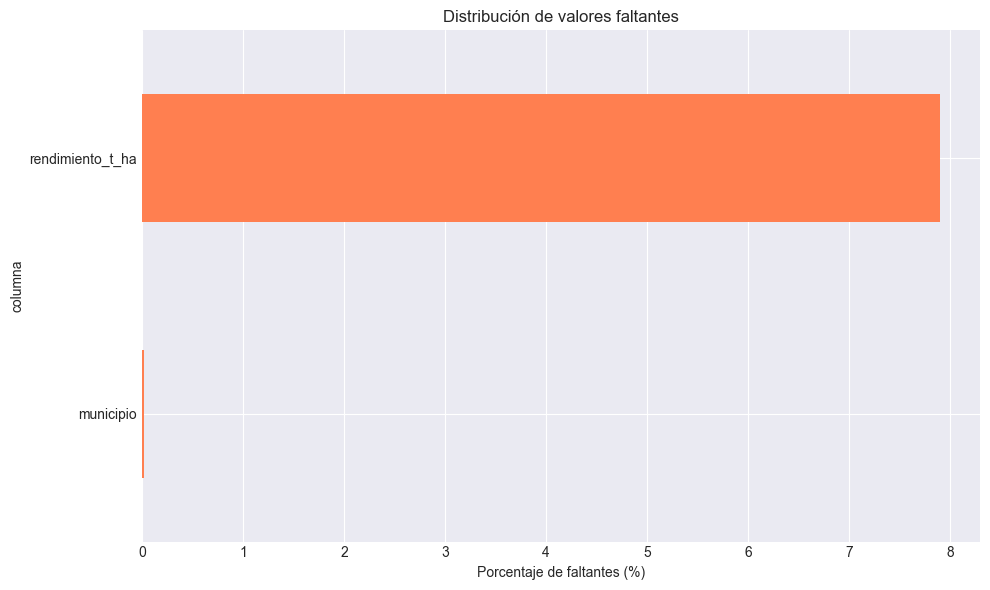

In [102]:
# Visualización del porcentaje de faltantes por columna
if df is not None and len(df) > 0:
    missing_data_plot = pd.DataFrame({
        'columna': df.columns,
        'porcentaje_faltante': (df.isnull().sum() / len(df) * 100).round(2)
    })
    missing_data_plot = missing_data_plot[missing_data_plot['porcentaje_faltante'] > 0].sort_values('porcentaje_faltante')

    if len(missing_data_plot) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        missing_data_plot.plot(
            kind='barh',
            x='columna',
            y='porcentaje_faltante',
            ax=ax,
            color='coral',
            legend=False
        )
        ax.set_xlabel('Porcentaje de faltantes (%)')
        ax.set_title('Distribución de valores faltantes')
        plt.tight_layout()
        plt.show()
    else:
        print('No hay faltantes para visualizar.')
else:
    print('No hay datos cargados.')

## 4. Distribuciones: diagnóstico estadístico base

In [103]:
# Estadísticos descriptivos para variables numéricas
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        print('Estadística descriptiva (variables numéricas):')
        print('=' * 100)
        display(df[numerical_cols].describe().T)
    else:
        print('No se encontraron columnas numéricas.')
else:
    print('No hay datos cargados.')

Estadística descriptiva (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
c_d_dep,5000.0,38.56980,25.558924,5.0,17.0,41.0,66.0,99.0
c_d_mun,5000.0,38980.79480,25535.410932,5001.0,17446.0,41020.0,66045.0,99524.0
a_o,5000.0,2013.03220,3.261057,2006.0,2010.0,2013.0,2016.0,2018.0
rea_sembrada_ha,5000.0,107.37860,330.003566,0.0,10.0,29.0,83.0,6548.0
rea_cosechada_ha,5000.0,75.66880,265.137582,0.0,5.0,17.0,54.0,6095.0
producci_n_t,5000.0,681.87160,2436.778684,0.0,24.0,118.5,430.0,58146.0
rendimiento_t_ha,4605.0,8.11192,4.796009,0.2,5.0,8.0,10.0,37.4


In [104]:
# Estadísticos para variables categóricas
if df is not None and len(df) > 0:
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    if len(categorical_cols) > 0:
        print('Resumen de variables categóricas:')
        print('=' * 100)
        for col in categorical_cols:
            print(f'\n{col}:')
            print(f'  Valores únicos: {df[col].nunique()}')
            print('  Valores más frecuentes:')
            print(df[col].value_counts().head())
    else:
        print('No se encontraron columnas categóricas.')
else:
    print('No hay datos cargados.')

Resumen de variables categóricas:

departamento:
  Valores únicos: 30
  Valores más frecuentes:
departamento
ANTIOQUIA          812
HUILA              442
VALLE DEL CAUCA    405
CUNDINAMARCA       402
CALDAS             286
Name: count, dtype: int64

municipio:
  Valores únicos: 565
  Valores más frecuentes:
municipio
EL PEÑON                   26
LOS PATIOS                 24
EL CANTON DEL SAN PABLO    24
GIGANTE                    24
ISNOS                      24
Name: count, dtype: int64

grupo_de_cultivo:
  Valores únicos: 4
  Valores más frecuentes:
grupo_de_cultivo
FRUTALES                                            4342
TUBERCULOS Y PLATANOS                                372
HORTALIZAS                                           217
PLANTAS AROMATICAS, CONDIMENTARIAS Y MEDICINALES      69
Name: count, dtype: int64

subgrupo_de_cultivo:
  Valores únicos: 8
  Valores más frecuentes:
subgrupo_de_cultivo
AGUACATE                  4298
ACELGA                     215
ACHIRA            

## 4.1 Distribuciones numéricas, asimetría y necesidad de transformación

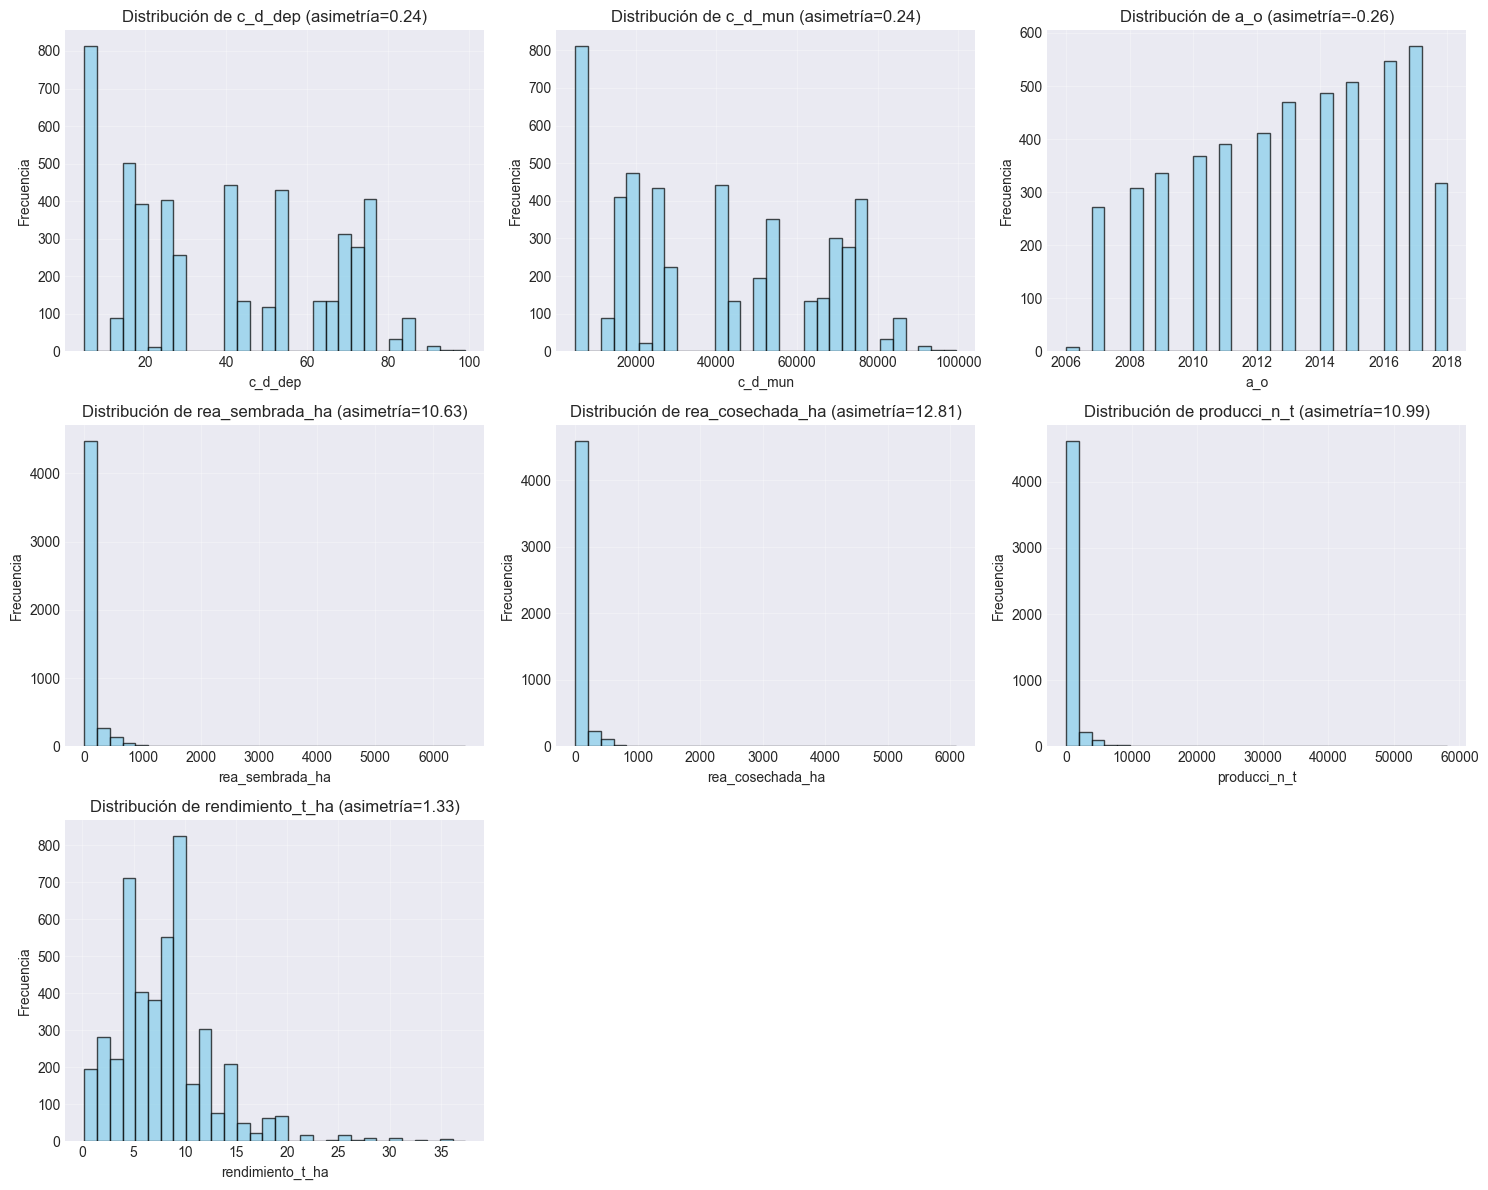

Variables con asimetría alta (|skew| > 1), candidatas a transformación:
['rea_sembrada_ha', 'rea_cosechada_ha', 'producci_n_t', 'rendimiento_t_ha']


In [88]:
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        n_cols = len(numerical_cols)
        n_rows = (n_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
        axes = axes.flatten()

        for idx, col in enumerate(numerical_cols):
            series = df[col].dropna()
            axes[idx].hist(series, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
            skew = series.skew()
            axes[idx].set_title(f'Distribución de {col} (asimetría={skew:.2f})')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frecuencia')
            axes[idx].grid(True, alpha=0.3)

        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

        high_skew = [c for c in numerical_cols if abs(df[c].dropna().skew()) > 1]
        if high_skew:
            print('Variables con asimetría alta (|skew| > 1), candidatas a transformación:')
            print(high_skew)
        else:
            print('No se detectó asimetría alta en variables numéricas.')
    else:
        print('No hay columnas numéricas para visualizar.')
else:
    print('No hay datos cargados.')

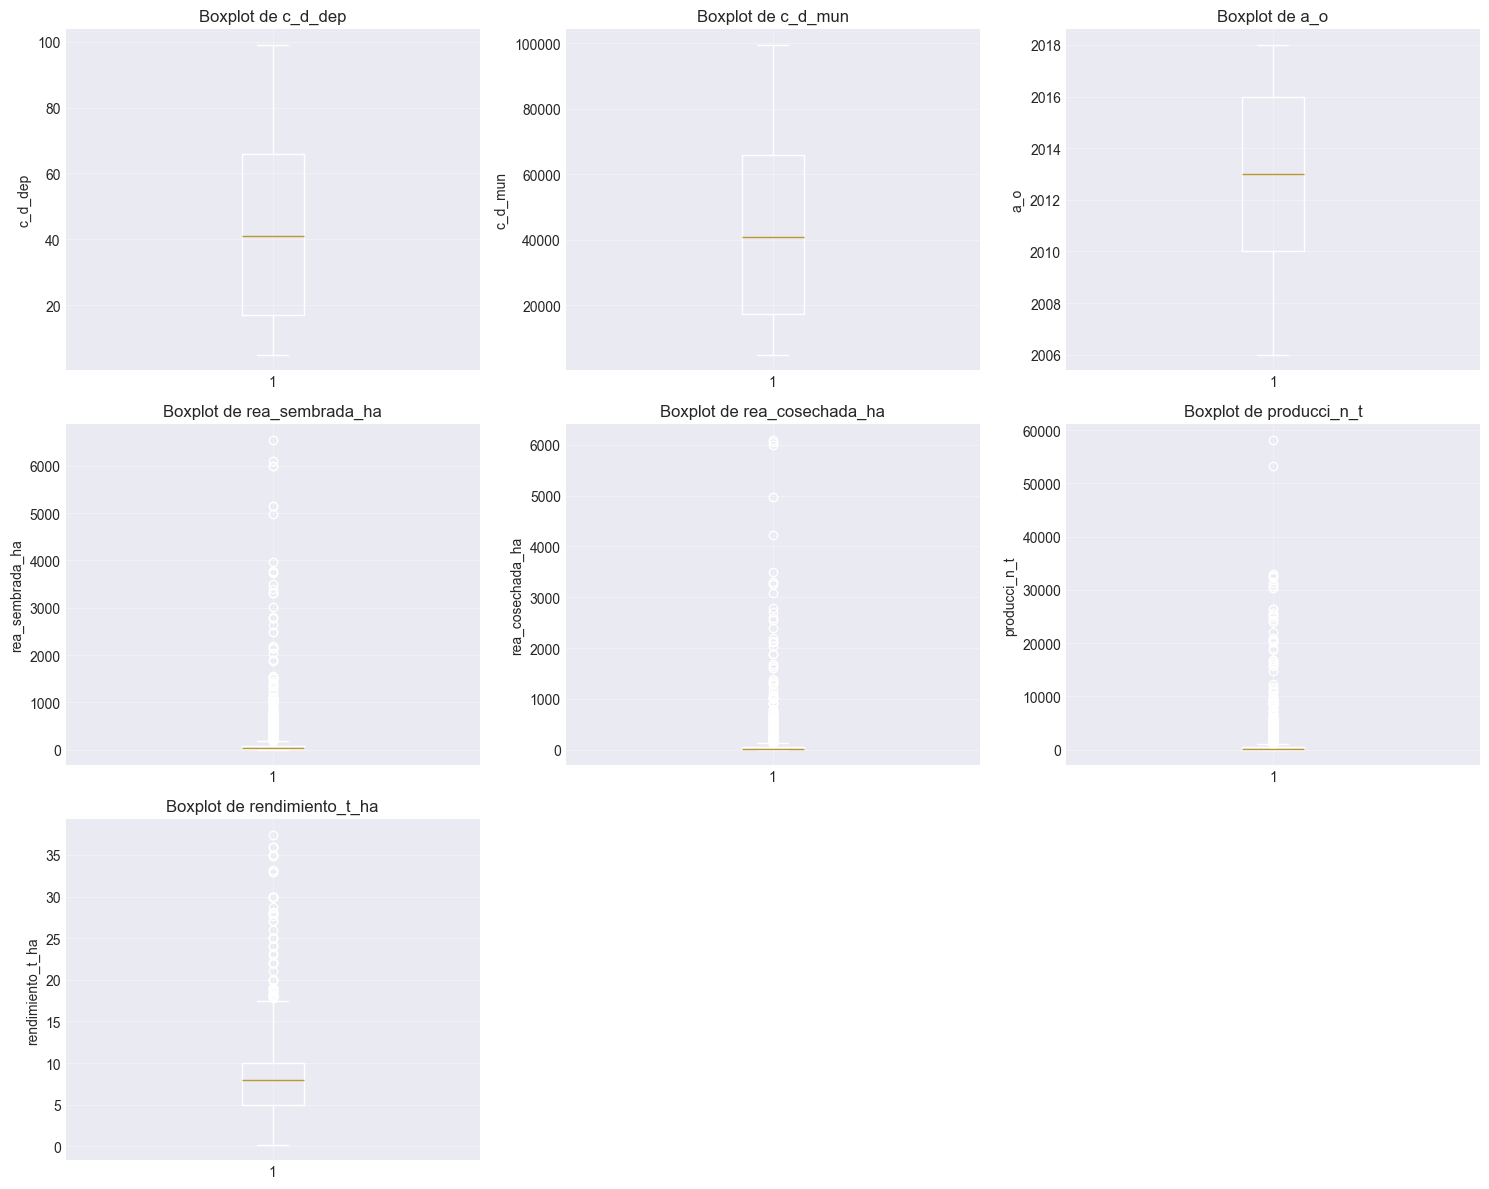

In [89]:
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        n_cols = len(numerical_cols)
        n_rows = (n_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
        axes = axes.flatten()

        for idx, col in enumerate(numerical_cols):
            axes[idx].boxplot(df[col].dropna())
            axes[idx].set_title(f'Boxplot de {col}')
            axes[idx].set_ylabel(col)
            axes[idx].grid(True, alpha=0.3)

        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()
    else:
        print('No hay columnas numéricas para visualizar.')
else:
    print('No hay datos cargados.')

## 5. Relación entre variables (correlación, redundancia y multicolinealidad)

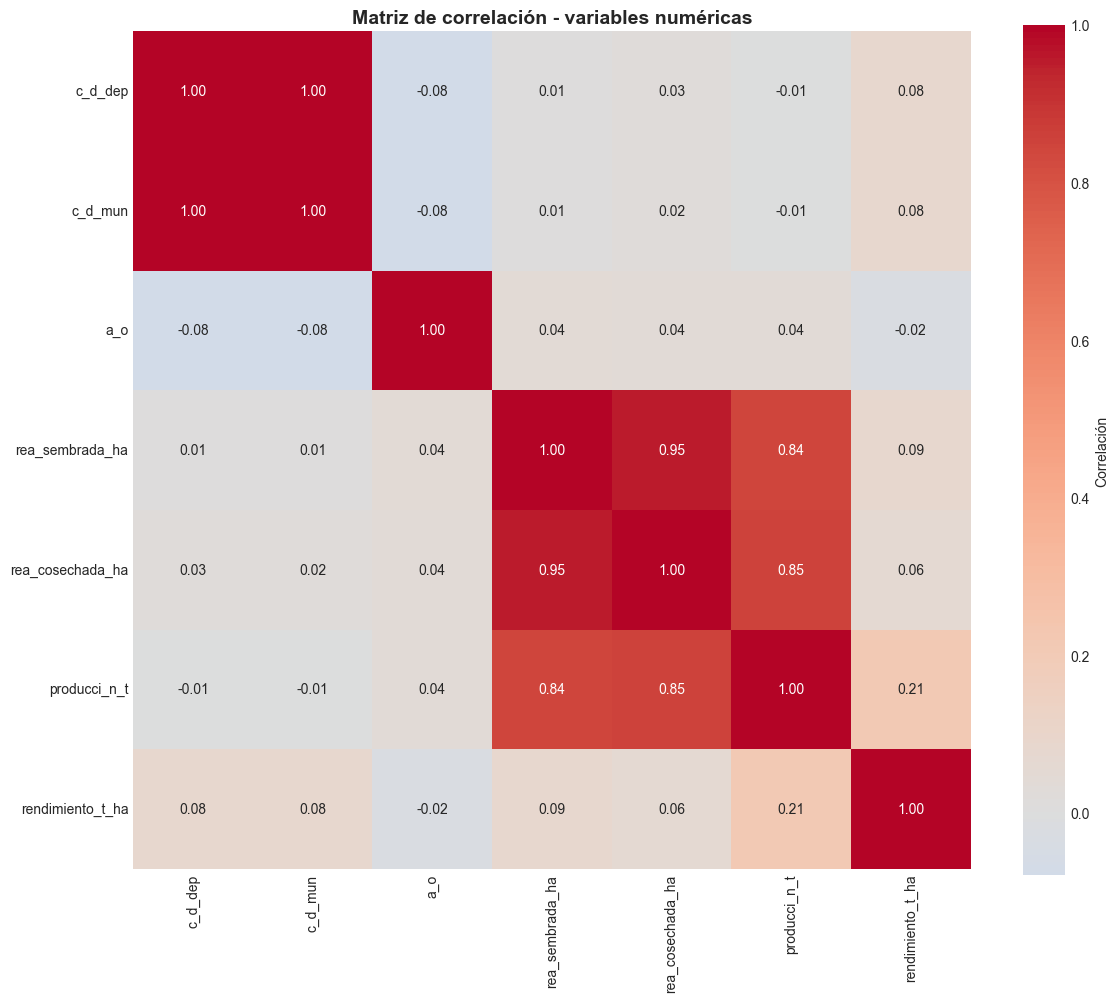


Pares altamente correlacionados (|correlación| > 0.7):


,Variable_1,Variable_2,Correlacion
0,c_d_dep,c_d_mun,0.999946
1,rea_sembrada_ha,rea_cosechada_ha,0.949812
3,rea_cosechada_ha,producci_n_t,0.848904
2,rea_sembrada_ha,producci_n_t,0.844838


In [90]:
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 1:
        corr_matrix = df[numerical_cols].corr()

        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax,
            cbar_kws={'label': 'Correlación'}
        )
        ax.set_title('Matriz de correlación - variables numéricas', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('\nPares altamente correlacionados (|correlación| > 0.7):')
        print('=' * 80)
        corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.7:
                    corr_pairs.append({
                        'Variable_1': corr_matrix.columns[i],
                        'Variable_2': corr_matrix.columns[j],
                        'Correlacion': corr_matrix.iloc[i, j]
                    })

        if corr_pairs:
            corr_df = pd.DataFrame(corr_pairs)
            display(corr_df.sort_values('Correlacion', key=lambda s: s.abs(), ascending=False))
        else:
            print('No se encontraron pares altamente correlacionados.')
    else:
        print('No hay suficientes variables numéricas para análisis de correlación.')
else:
    print('No hay datos cargados.')

## 4.2 Distribuciones en variables categóricas

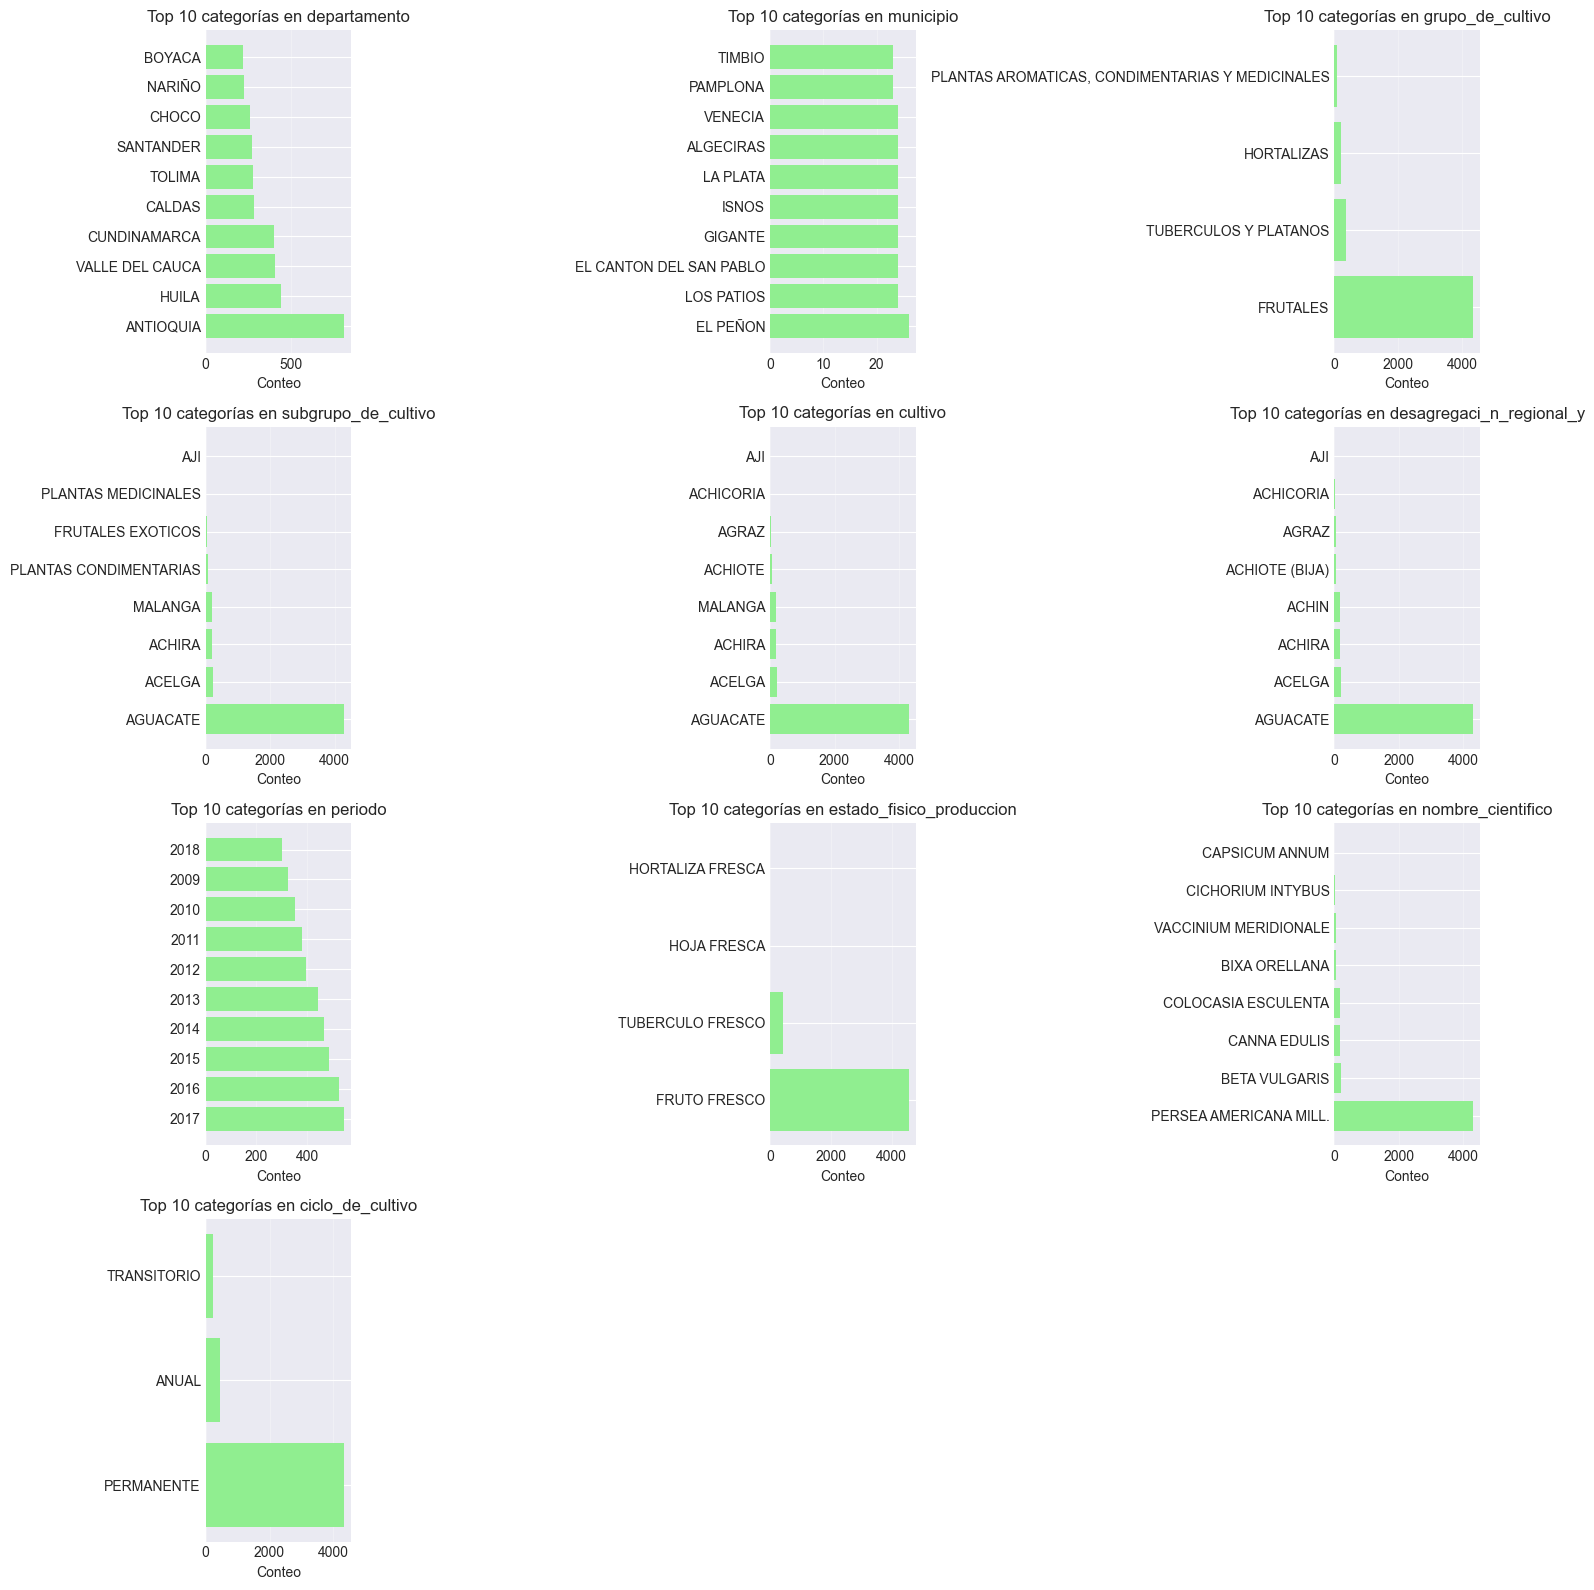

In [91]:
if df is not None and len(df) > 0:
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    if len(categorical_cols) > 0:
        n_cat_cols = len(categorical_cols)
        n_rows = (n_cat_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
        axes = axes.flatten()

        for idx, col in enumerate(categorical_cols):
            top_values = df[col].value_counts().head(10)
            axes[idx].barh(range(len(top_values)), top_values.values, color='lightgreen')
            axes[idx].set_yticks(range(len(top_values)))
            axes[idx].set_yticklabels(top_values.index)
            axes[idx].set_title(f'Top 10 categorías en {col}')
            axes[idx].set_xlabel('Conteo')
            axes[idx].grid(True, alpha=0.3, axis='x')

        for idx in range(len(categorical_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()
    else:
        print('No se encontraron columnas categóricas.')
else:
    print('No hay datos cargados.')

## 4.3 Detección de outliers

In [92]:
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        outlier_summary = []

        for col in numerical_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

            if len(outliers) > 0:
                outlier_summary.append({
                    'columna': col,
                    'cantidad_outliers': len(outliers),
                    'porcentaje_outliers': round((len(outliers) / len(df)) * 100, 2),
                    'limite_inferior': lower_bound,
                    'limite_superior': upper_bound
                })

        if outlier_summary:
            outlier_df = pd.DataFrame(outlier_summary).sort_values('porcentaje_outliers', ascending=False)
            print('Resumen de outliers (método IQR):')
            print('=' * 100)
            display(outlier_df)
        else:
            print('No se detectaron outliers con el método IQR.')
    else:
        print('No hay variables numéricas para detección de outliers.')
else:
    print('No hay datos cargados.')

Resumen de outliers (método IQR):


,columna,cantidad_outliers,porcentaje_outliers,limite_inferior,limite_superior
2,producci_n_t,659,13.18,-585.0,1039.0
1,rea_cosechada_ha,620,12.40,-68.5,127.5
0,rea_sembrada_ha,604,12.08,-99.5,192.5
3,rendimiento_t_ha,207,4.14,-2.5,17.5


## 6. Relación con la variable objetivo

Esta sección evalúa capacidad de separación entre clases y relevancia predictiva de las variables numéricas seleccionadas.

Evaluación de separabilidad para clasificación:
- Clases con al menos 10 registros: 3
Top variables con mayor separabilidad entre clases (ANOVA):


,variable,f_stat,p_value
6,rendimiento_t_ha,238.683669,2.356238e-99
3,rea_sembrada_ha,18.099277,1.472033e-08
5,producci_n_t,13.927826,9.290073e-07
4,rea_cosechada_ha,11.130693,1.502233e-05
1,c_d_mun,7.280656,6.960644e-04
0,c_d_dep,7.149749,7.931183e-04
2,a_o,1.127698,3.238600e-01


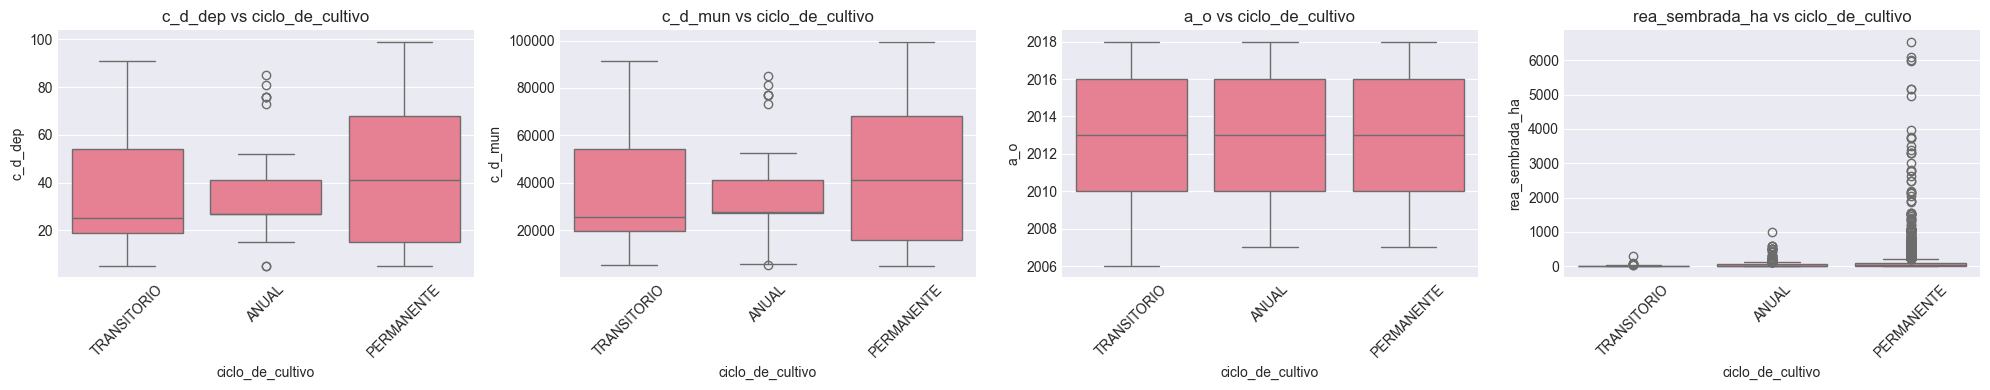


No se detectaron variables numéricas con varianza nula.


In [93]:
# Separabilidad y utilidad de variables respecto al objetivo
if df is not None and len(df) > 0 and TARGET_COLUMN in df.columns:
    target = TARGET_COLUMN
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target]

    if len(numeric_cols) == 0:
        print('No hay variables numéricas para evaluar separabilidad.')
    else:
        y = df[target]
        y_non_null = y.dropna()
        n_unique = y_non_null.nunique()
        is_classification = (y.dtype == 'object') or (n_unique <= 20)

        # Ranking simple por correlación absoluta (si objetivo numérico)
        if not is_classification and pd.api.types.is_numeric_dtype(df[target]):
            corr_target = df[numeric_cols + [target]].corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
            print('Variables numéricas más relacionadas con el objetivo (|correlación|):')
            display(corr_target.to_frame('corr_abs_con_objetivo').head(10))

        # Para clasificación: diferencia de medias entre clases (ANOVA simple cuando aplica)
        else:
            print('Evaluación de separabilidad para clasificación:')
            class_counts = y.value_counts(dropna=True)
            valid_classes = class_counts[class_counts >= 10].index.tolist()
            print(f'- Clases con al menos 10 registros: {len(valid_classes)}')

            separability_rows = []
            for col in numeric_cols:
                groups = [df.loc[df[target] == cls, col].dropna().values for cls in valid_classes]
                groups = [g for g in groups if len(g) >= 10]
                if len(groups) >= 2:
                    try:
                        f_stat, p_value = stats.f_oneway(*groups)
                        separability_rows.append({
                            'variable': col,
                            'f_stat': float(f_stat),
                            'p_value': float(p_value)
                        })
                    except Exception:
                        pass

            if separability_rows:
                sep_df = pd.DataFrame(separability_rows).sort_values('f_stat', ascending=False)
                print('Top variables con mayor separabilidad entre clases (ANOVA):')
                display(sep_df.head(10))
            else:
                print('No fue posible calcular separabilidad robusta con las clases actuales.')

        # Visualización de variables candidatas útiles
        top_vars = numeric_cols[:4] if len(numeric_cols) >= 4 else numeric_cols
        if top_vars:
            n = len(top_vars)
            fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
            if n == 1:
                axes = [axes]
            for i, col in enumerate(top_vars):
                sns.boxplot(data=df, x=target, y=col, ax=axes[i])
                axes[i].set_title(f'{col} vs {target}')
                axes[i].tick_params(axis='x', rotation=45)
            plt.tight_layout()
            plt.show()

        # Señal de variables posiblemente inútiles
        low_var = [c for c in numeric_cols if df[c].nunique(dropna=True) <= 1]
        if low_var:
            print('\nVariables numéricas potencialmente inútiles (varianza nula):')
            print(low_var)
        else:
            print('\nNo se detectaron variables numéricas con varianza nula.')
else:
    print('No se puede evaluar relación con objetivo: valida que TARGET_COLUMN esté definido y exista.')

## 7. Balance entre clases e implicaciones

Se analiza la distribución de la variable objetivo para anticipar riesgos de sesgo y definir métricas de evaluación adecuadas.

In [94]:
# Análisis de balance de clases
if df is not None and len(df) > 0 and TARGET_COLUMN in df.columns:
    y = df[TARGET_COLUMN].dropna()
    is_classification = (y.dtype == 'object') or (y.nunique() <= 20)

    if is_classification:
        class_dist = y.value_counts().to_frame('conteo')
        class_dist['porcentaje'] = (class_dist['conteo'] / class_dist['conteo'].sum() * 100).round(2)
        class_dist = class_dist.reset_index().rename(columns={'index': 'clase'})
        display(class_dist)

        ratio = class_dist['conteo'].max() / class_dist['conteo'].min()
        print(f'Ratio clase mayoritaria/minoritaria: {ratio:.2f}')

        plt.figure(figsize=(10, 4))
        sns.barplot(data=class_dist, x='clase', y='conteo', color='steelblue')
        plt.title(f'Distribución de clases en {TARGET_COLUMN}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print('\nImplicaciones para modelado:')
        if ratio >= 3:
            print('- Existe desbalance relevante; usar partición estratificada.')
            print('- Priorizar métricas robustas: F1 macro, balanced accuracy, ROC-AUC por clase.')
            print('- Evaluar remuestreo (SMOTE/undersampling) o ponderación de clases.')
        else:
            print('- El balance es razonable para comenzar con modelos base.')
            print('- Mantener validación estratificada y monitorear métricas por clase.')
    else:
        print('La variable objetivo parece de regresión; no aplica balance de clases.')
else:
    print('No se puede analizar balance: valida que TARGET_COLUMN esté definido y exista.')

,ciclo_de_cultivo,conteo,porcentaje
0,PERMANENTE,4342,86.84
1,ANUAL,435,8.70
2,TRANSITORIO,223,4.46


Ratio clase mayoritaria/minoritaria: 19.47


ValueError: Could not interpret value `clase` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x400 with 0 Axes>

## 8. Conclusiones y preparación del dataset para entrenamiento

### Síntesis técnica de resultados

1. Contenido y estructura del dataset
- Se trabajó con **5000 registros** y 17 variables del sistema agrícola reportado en fuente oficial.
- Tras estandarización de tipos, se identificaron 7 variables numéricas útiles para modelado.

2. Calidad de datos
- Se detectaron faltantes en `rendimiento_t_ha` y en menor proporción en `municipio`.
- No se identificaron duplicados exactos en la muestra analizada.
- No se observaron inconsistencias graves de formato en la revisión inicial de variables categóricas.

3. Transformaciones necesarias
- Conversión de variables numéricas inicialmente cargadas como texto.
- Tratamiento explícito de faltantes antes del entrenamiento.
- Revisión de asimetría y outliers para definir transformaciones donde aplique.

4. Adecuación para aprendizaje automático
- Variable objetivo definida: `ciclo_de_cultivo` (clasificación multiclase).
- El conjunto cumple criterios mínimos de la entrega: volumen, número de variables numéricas y objetivo modelable.
- El dataset es apto para continuar con entrenamiento, condicionado a completar el preprocesamiento documentado.

### Decisiones recomendadas previas al modelado

- Imputar o excluir faltantes según impacto por variable.
- Mantener partición estratificada por la variable objetivo.
- Evaluar métricas por clase (F1 macro y balanced accuracy) para evitar sesgo por distribución.
- Documentar cualquier eliminación de variables por redundancia o baja utilidad predictiva.

---

## Información del notebook

- Materia: Programación Avanzada
- Profesor: Jaime Alberto Vergara Tejada
- Autor: Diego Alejandro Ríos Vásquez
- Fecha de actualización: 2026-04-24
- Dataset: Colombia EVA
- Fuente: Datos.gov.co (API Socrata SODA)
- Dataset ID: 2pnw-mmge
- Propósito: EDA y alistamiento del dataset para aprendizaje automático